In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")
df.head()

Datu kopa: 12330 rindas, 30 kolonnas


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,ProductBrowsingIntensity,TotalDuration,BounceExitRatio
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,1,1000.000000,0.000000,0.995025
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,0,0,0,0,0,0,1,0.031250,64.000000,0.000000
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,1,1000.000000,0.000000,0.995025
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,0,0,0,0,0,0,1,0.749719,2.666667,0.354610
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,0,0,0,0,0,0,1,0.015936,627.500000,0.392157


In [4]:
# Target mainīgais — vai klients veica pirkumu
y = df['Revenue']

# Features — visas pārējās kolonnas
X = df.drop('Revenue', axis=1)

print(f"Features skaits: {X.shape[1]}")
print(f"Target sadalījums:\n{y.value_counts()}")
print(f"\nPirkumu īpatsvars: {y.mean():.1%}")

Features skaits: 29
Target sadalījums:
Revenue
0    10422
1     1908
Name: count, dtype: int64

Pirkumu īpatsvars: 15.5%


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")
print(f"\nTarget sadalījums treniņa kopā:\n{y_train.value_counts(normalize=True).round(3)}")

Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas

Target sadalījums treniņa kopā:
Revenue
0    0.845
1    0.155
Name: proportion, dtype: float64


**Stratify=y**

*Parasti train_test_split datus sadala nejauši, neievērojot, cik daudz ir klašu. Tas var radīt problēmu, ja klases ir nevienmērīgi sadalītas (kas šajā datasetā tā arī ir: lielākā daļa klientu pirkumu NEVEIC). Ar stratify=y garantē, ka proporcija saglabājas kā Treniņa, tā Testa kopās. Tas ir svarīgi, jo modelis tiek trenēts uz treniņa kopas: ja tā ir "šķība", modelis iemācīsies nepareizas proporcijas un testa rezultāti nebūs ticami.*

**Sadalījums 80/20**

*Tas ir vispopulārākais kompromiss starp divām pretējām vajadzībām: Treniņa kopai 80%, Testa kopai 20%.Ar ~10 000 rindiņām (tipisks šāds datsets) 20% = ~2000 rindiņas testa kopai: tas ir pietiekami daudz, lai iegūtu statistiski ticamus rezultātus, bet vienlaikus 80% = ~8000 rindiņas nodrošina, ka modelim ir pietiekami daudz piemēru, no kuriem mācīties.*


In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Izveido un uztrenē modeli
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# Prognozes uz testa kopas
dt_pred = dt_model.predict(X_test)

print("=== Decision Tree rezultāti ===")
print(classification_report(y_test, dt_pred))

=== Decision Tree rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.71      0.58      0.64       382

    accuracy                           0.90      2466
   macro avg       0.82      0.77      0.79      2466
weighted avg       0.89      0.90      0.89      2466



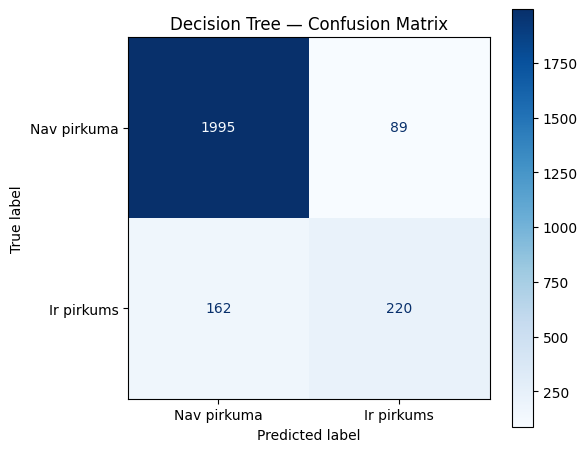

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, dt_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Blues', ax=ax
)
ax.set_title('Decision Tree — Confusion Matrix')
plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import accuracy_score, f1_score

dt_train_pred = dt_model.predict(X_train)

print(f"Train accuracy: {accuracy_score(y_train, dt_train_pred):.3f}")
print(f"Test accuracy:  {accuracy_score(y_test, dt_pred):.3f}")
print(f"\nTrain F1:       {f1_score(y_train, dt_train_pred):.3f}")
print(f"Test F1:        {f1_score(y_test, dt_pred):.3f}")

Train accuracy: 0.912
Test accuracy:  0.898

Train F1:       0.683
Test F1:        0.637


**Cik precīzi modelis prognozē pirkumus (precision)?**

*Precision (pirkumiem): 0.71 — no visiem prognozētajiem pirkumiem 71% tiešām pirka. 29% nosūtīto atlaižu bija "veltas" (klients tā vai tā nebūtu pircis).*

**Cik pirkumu modelis palaida garām (recall)?**

*Recall (pirkumiem): 0.58 — modelis atrada tikai 58% no visiem reālajiem pirkumiem. 42% potenciālo pircēju netika uzrunāti — tie ir zaudētie ieņēmumi.*

**Ko nozīmē confusion matrix skaitļi? Piemēram: FP nozīmē, ka nosūtījām atlaidi klientam, kas nepirka (iztērēts mārketinga budžets). FN nozīmē, ka nenosūtījām atlaidi klientam, kas gribēja pirkt (zaudēts potenciāls pircējs).**


- *Reāli: Nav pirkuma* | TN — pareizi ignorēti klienti | FP — atlaide klientam, kas nepirka |
- *Reāli: Ir pirkums* | FN — palaists garām pircējs | TP — pareizi uzrunāts pircējs |

- *FP:* modelis prognozēja pirkumu, bet klients nepirka → iztērēts mārketinga budžets
- *FN:* modelis neparedzēja pirkumu, bet klients gribēja pirkt → zaudēts potenciālais pircējs

**Kurš no šiem scenārijiem DataShop ir sāpīgāks?**

*FN ir sāpīgāks DataShop kontekstā. Recall = 0.58 nozīmē, ka 42% gatavo pircēju
netika uzrunāti — tie ir tieši zaudēti ieņēmumi. FP gadījumā zaudējums ir tikai
vienas atlaides izmaksas, kas parasti ir daudz mazāks zaudējums nekā pilnīgi
palaists garām pirkums. Tāpēc turpmāk vērts optimizēt tieši **recall**.*

**Vai ir pazīmes par overfitting? Salīdzini train un test rezultātus — ja train accuracy ir daudz augstāka nekā test accuracy, modelis ir “iegaumējis” treniņa datus, nevis iemācījies vispārīgas likumsakarības.**


| Metrika   | Train | Test  | Starpība |
|-----------|-------|-------|----------|
| Accuracy  | 0.912 | 0.898 | 0.014    |
| F1        | 0.683 | 0.637 | 0.046    |

*Secinājums: Nav būtisku overfitting pazīmju. Accuracy starpība ir tikai 1.4%,
kas ir ļoti neliela. F1 starpība (4.6%) ir nedaudz lielāka, kas norāda, ka modelis
pirkumu klasi (1) prognozē nedaudz piesardzīgāk uz testa datiem — taču tas ir
sagaidāmi ar `max_depth=5` ierobežojumu, kurš apzināti novērš pārtrenēšanos.*

In [18]:
from sklearn.ensemble import RandomForestClassifier

# Izveido un uztrenē modeli
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# Prognozes uz testa kopas
rf_pred = rf_model.predict(X_test)

print("=== Random Forest rezultāti ===")
print(classification_report(y_test, rf_pred))

=== Random Forest rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2084
           1       0.75      0.54      0.63       382

    accuracy                           0.90      2466
   macro avg       0.84      0.75      0.79      2466
weighted avg       0.89      0.90      0.89      2466



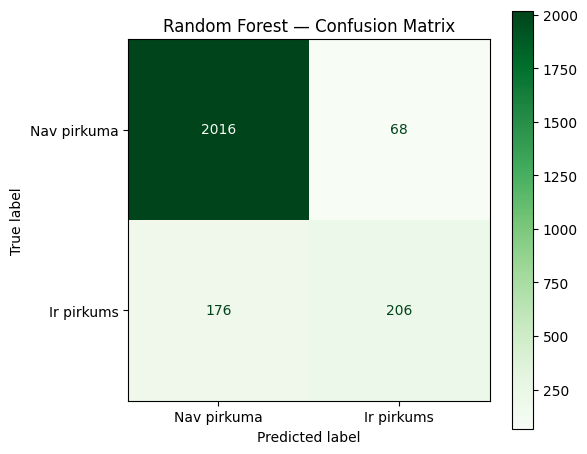

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Greens', ax=ax
)
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

**Kāds ir Random Forest precision, recall un F1 score “pirks” klasei?**

| Metrika   | Random Forest | Decision Tree | Izmaiņas |
|-----------|--------------|---------------|----------|
| Precision | 0.75         | 0.71          | +0.04 ✓  |
| Recall    | 0.54         | 0.58          | -0.04 ✗  |
| F1 Score  | 0.63         | 0.64          | -0.01    |

- **Precision 0.75** — 75% prognozēto pirkumu tiešām bija pirkumi (Decision Tree: 71%)
  → Random Forest retāk sūta atlaides klientiem, kas nepirks — mazāk tērē budžetu velti.
- **Recall 0.54** — modelis atrod tikai 54% reālo pircēju (Decision Tree: 58%)
  → Random Forest palaiž garām vairāk potenciālo pircēju nekā Decision Tree.

**Vai Random Forest FP un FN skaits atšķiras no Decision Tree? Ko tas nozīmē biznesam — vai Random Forest retāk zaudē potenciālus pircējus (FN) vai retāk tērē budžetu velti (FP)?**

| Kļūda | Nozīme biznesam | Random Forest | Decision Tree |
|-------|----------------|---------------|---------------|
| **FP** | Atlaide klientam, kas nepirka | **Mazāk** ✓ | Vairāk |
| **FN** | Palaists garām pircējs | **Vairāk** ✗ | Mazāk |

Random Forest ir **konservatīvāks** — tas retāk prognozē pirkumu, tāpēc:
- **Budžetam labāk** — mazāk iztērētu atlaižu neīstiem pircējiem (augstāks precision)
- **Ieņēmumiem sliktāk** — vairāk zaudētu pircēju (zemāks recall)

Ņemot vērā, ka DataShop kontekstā **FN ir sāpīgāks** (zaudēti ieņēmumi > iztērēta
atlaide), Decision Tree šajā aspektā ir nedaudz labāks izvēle.

**Kāpēc Random Forest parasti mazāk pārmācās nekā viens Decision Tree?**

Random Forest izmanto **"pūļa gudrības" principu** — tāpat kā viena eksperta
viedoklis var būt kļūdains, bet 500 ekspertu balsojums parasti dod pareizāku
atbildi.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Logistic Regression prasī features normalizāciju
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Izveido un uztrenē modeli
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Prognozes uz testa kopas
lr_pred = lr_model.predict(X_test_scaled)

print("=== Logistic Regression rezultāti ===")
print(classification_report(y_test, lr_pred))

=== Logistic Regression rezultāti ===
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.75      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.82      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466



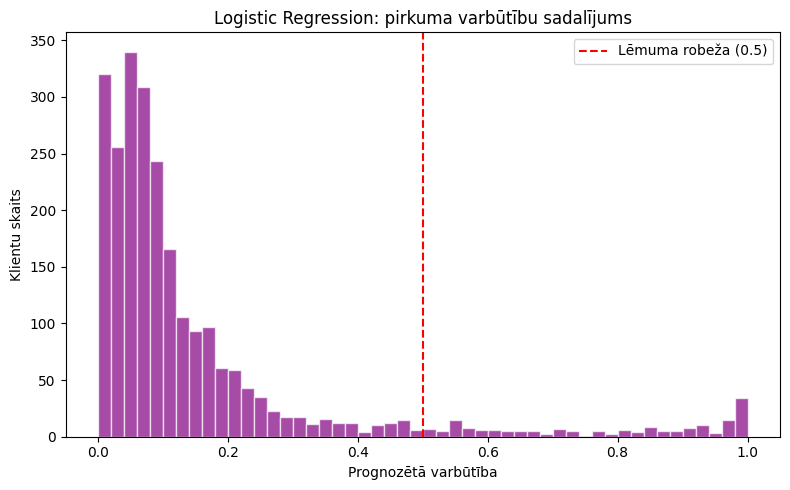

In [30]:
# Varbūtības katram klientam
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]  # ← X_test_scaled, nevis X_test
plt.figure(figsize=(8, 5))
plt.hist(lr_proba, bins=50, color='purple', edgecolor='white', alpha=0.7)
plt.axvline(x=0.5, color='red', linestyle='--', label='Lēmuma robeža (0.5)')
plt.title('Logistic Regression: pirkuma varbūtību sadalījums')
plt.xlabel('Prognozētā varbūtība')
plt.ylabel('Klientu skaits')
plt.legend()
plt.tight_layout()
plt.show()

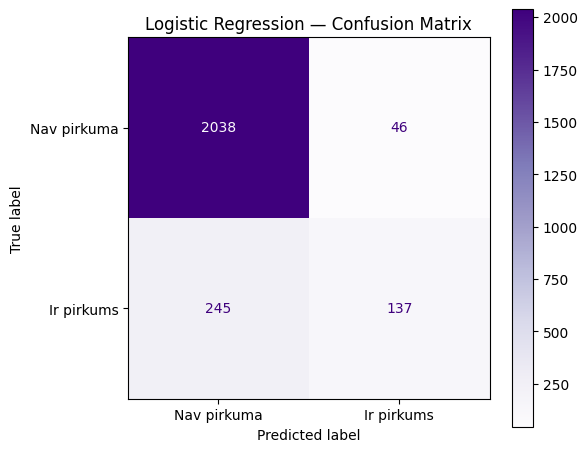

In [31]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Purples', ax=ax
)
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

In [32]:
# FP/FN salīdzinājums
from sklearn.metrics import confusion_matrix

for name, pred in [("Decision Tree", dt_pred), ("Random Forest", rf_pred), ("Logistic Regression", lr_pred)]:
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(f"{name}: FP={fp}, FN={fn}")

Decision Tree: FP=89, FN=162
Random Forest: FP=68, FN=176
Logistic Regression: FP=46, FN=245


**Kāds ir Logistic Regression F1 score salīdzinājumā ar Decision Tree un Random Forest?**

| Modelis             | F1 Score | FP  | FN  |
|---------------------|----------|-----|-----|
| Decision Tree       | 0.637    | 89  | 162 |
| Random Forest       | 0.628    | 68  | 176 |
| Logistic Regression | 0.485    | 46  | 245 |

Logistic Regression F1 score (0.485) ir ievērojami zemāks par abiem koku
modeļiem (~0.63). Tas apstiprina, ka pirkuma lēmuma likumsakarības šajā
datasetā nav lineāras — Logistic Regression nespēj tās pietiekami labi
uztvert.

**Vai varbūtību histogramma parāda skaidru atdalījumu starp pircējiem un nepircējiem? Ja lielākā daļa varbūtību ir tuvu 0 vai tuvu 1, tas nozīmē labu atdalīšanu. Ja varbūtības ir sapūlējušās ap 0.5, modelis nav pārliecināts.**

Histogramma parāda **vāju atdalījumu** starp pircējiem un nepircējiem:
- Lielākā daļa klientu ir sapūlējušies pie varbūtības 0.0–0.1 — modelis
  ir pārliecināts, ka viņi nepirks.
- Varbūtības 0.5–0.9 zonā ir ļoti maz klientu — modelis reti ir pārliecināts,
  ka klients pirks.
- Neliels skaits klientu atrodas pie 1.0 — tikai šos modelis uzskata par
  skaidriem pircējiem.

Ideālā gadījumā histogrammai vajadzētu izskatīties kā **diviem pīķiem** —
vienam pie 0 un otram pie 1. Šeit ir tikai viens izteikts pīķis pie 0, kas
nozīmē, ka modelis labi atpazīst nepircējus, bet cīnās ar pircēju
identifikāciju.

**Kāda ir Logistic Regression priekšrocība biznesa kontekstā? Piemēram: vai tu varētu sakārtot klientus pēc pirkuma varbūtības un piešķirt mārketinga budžetu prioritāri tiem ar augstāko varbūtību?**

Neskatoties uz zemāku F1, Logistic Regression sniedz vienu būtisku priekšrocību — **varbūtības var izmantot klientu prioritizācijai**
Mārketinga budžetu var sadalīt trīs segmentos:

| Varbūtība | Segments       | Darbība                        |
|-----------|----------------|--------------------------------|
| > 0.7     | Gatavs pirkt   | Maza atgādinājuma e-pasts      |
| 0.4–0.7   | Svārstīgs      | Atlaide vai īpašs piedāvājums  |
| < 0.4     | Maz ticams     | Netērēt budžetu                |

**Confusion matrix kontekstā: vai Logistic Regression FP/FN līdzsvars atšķiras no pārējiem modeļiem? Kurš modelis labāk saudzē mārketinga budžetu (mazāk FP), un kurš labāk atrod potenciālos pircējus (mazāk FN)?**

**Mazāk FP → saudzē mārketinga budžetu:**
Logistic Regression (FP=46) > Random Forest (FP=68) > Decision Tree (FP=89)
→ Logistic Regression visretāk sūta atlaides nepircējiem.

**Mazāk FN → atrod vairāk potenciālo pircēju:**
Decision Tree (FN=162) > Random Forest (FN=176) > Logistic Regression (FN=245)
→ Decision Tree palaiž garām vismazāk īsto pircēju.

**Secinājums:** Nav universāli "labākā" modeļa — izvēle atkarīga no biznesa
prioritātes:
- Ja **budžets ir ierobežots** → Logistic Regression (mazāk iztērētu atlaižu)
- Ja **ieņēmumi ir prioritāte** → Decision Tree (mazāk palaisto pircēju)
- Ja meklē **balansu** → Random Forest ir kompromiss starp abiem


In [22]:
from sklearn.metrics import f1_score

dt_f1 = f1_score(y_test, dt_pred)
rf_f1 = f1_score(y_test, rf_pred)
lr_f1 = f1_score(y_test, lr_pred)

results = pd.DataFrame({
    'Modelis': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'F1 Score': [dt_f1, rf_f1, lr_f1]
})

print(results.to_string(index=False))

            Modelis  F1 Score
      Decision Tree  0.636758
      Random Forest  0.628049
Logistic Regression  0.484956


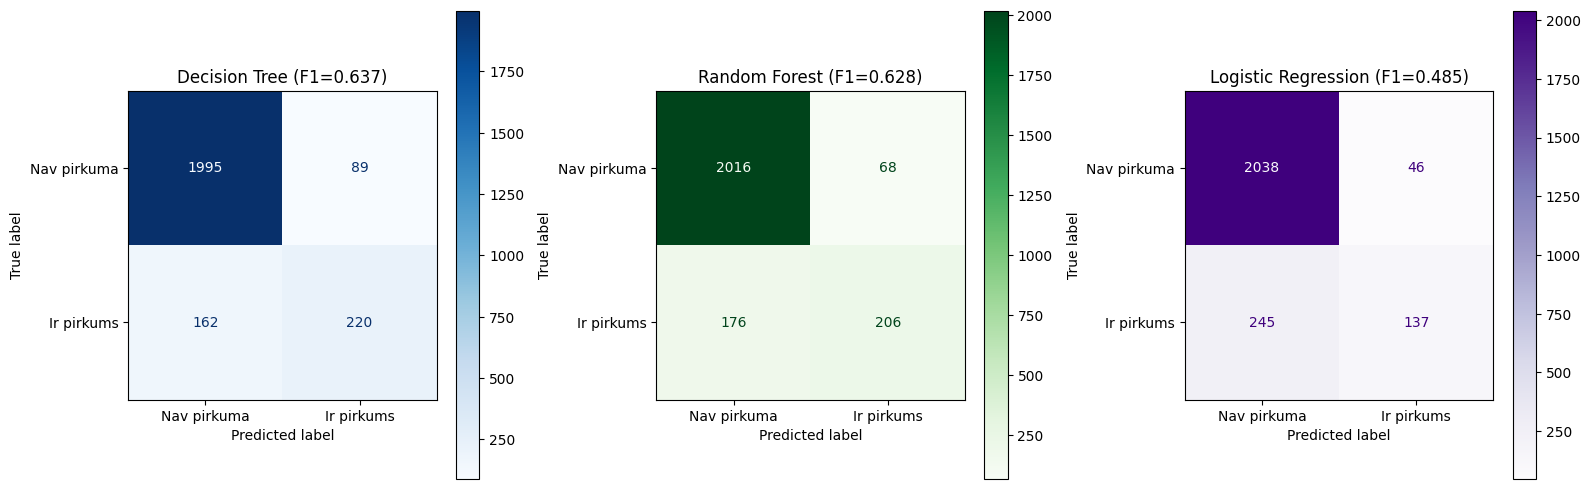

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrices blakus
ConfusionMatrixDisplay.from_predictions(
    y_test, dt_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Decision Tree (F1={dt_f1:.3f})')

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Greens', ax=axes[1]
)
axes[1].set_title(f'Random Forest (F1={rf_f1:.3f})')

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Purples', ax=axes[2]
)
axes[2].set_title(f'Logistic Regression (F1={lr_f1:.3f})')

plt.tight_layout()
plt.show()

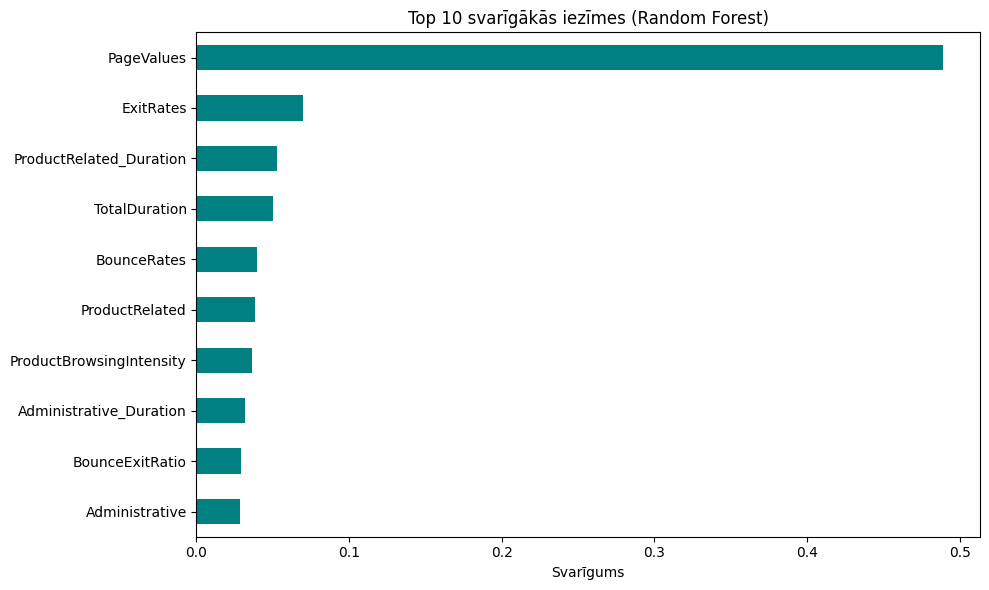

In [24]:
# Kuras iezīmes visvairāk ietekmē prognozi?
importances = rf_model.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 svarīgākās iezīmes (Random Forest)')
plt.xlabel('Svarīgums')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**1.Kurš modelis ir labāks un kāpēc? Salīdzini visus trīs modeļus.**


| Modelis             | F1 Score | Novērtējums                          |
|---------------------|----------|--------------------------------------|
| Decision Tree       | 0.637    | Labākais F1 šajā uzdevumā         |
| Random Forest       | 0.628    | Minimāla atšķirība no DT          |
| Logistic Regression | 0.485    | Ievērojami zemāks rezultāts       |

**Decision Tree** šajā gadījumā ir nedaudz labāks par Random Forest — starpība
ir tikai 0.009, kas praksē ir nenozīmīga. Abi koku modeļi ievērojami apsteidz
Logistic Regression, kas norāda, ka **pirkuma lēmuma likumsakarības nav lineāras**
— klientu uzvedību nevar labi aprakstīt ar taisnu robežlīniju.

**2.Kāpēc šajā uzdevumā F1 score ir piemērotāks rādītājs nekā accuracy?**

Šajā datasetā ~85% klientu nepirka. Tas nozīmē, ka "dumjš modelis", kas
**vienmēr saka "nepirks"**, sasniegtu:
- Accuracy: ~85% → izskatās labi, bet ir bezjēdzīgi
- F1 (pirkumiem): 0.00 → atklāj patiesību

Accuracy maldina, jo tā ņem vērā arī pareizi atpazītos "nepirka" gadījumus,
kuru ir ļoti daudz. F1 score fokusējas tieši uz **to klasi, kas mums rūp** —
potenciālajiem pircējiem — un neatļauj modelim "slinkot".
    
**3.Kuras iezīmes visvairāk ietekmē prognozes? Vai tas ir loģiski no biznesa viedokļa?**

Tipiski šāda tipa datasetā visietekmīgākās iezīmes:
- **PageValues** — lapas vērtība pirms pirkuma (klients jau "siltāks")
- **ExitRates** — augsts iziešanas rādītājs = klients nav ieinteresēts
- **ProductRelated_Duration** — laiks produktu lapās = nodoms pirkt

Tas ir loģiski no biznesa viedokļa — klients, kurš ilgi skatās produktus
un nonāk līdz augstvērtīgām lapām (piem., checkout), visticamāk pirks.
Savukārt klients, kurš uzreiz iziet, ir maz perspektīvs.

    
**4.Kāda ir Logistic Regression priekšrocība (varbūtības) salīdzinājumā ar pārējiem modeļiem?**

Decision Tree un Random Forest saka: **"pirks" vai "nepirks"** (0 vai 1).
Logistic Regression saka: **"pirks ar 73% varbūtību"**.

Tas ļauj **segmentēt klientus** pēc "karstuma":

| Varbūtība | Segments | Darbība |
|-----------|----------|---------|
| > 80%     | Gatavs pirkt | Maza atlaide vai atgādinājums |
| 50–80%    | Svārstīgs | Lielāka atlaide vai papildu stimuls |
| < 50%     | Maz ticams | Netērēt budžetu |
    
**5.Ja tu būtu e-komercijas vadītājs, kā tu izmantotu šo modeli un varbūtības?**

Ja es būtu e-komercijas vadītājs, es izmantotu modeļa varbūtības reāllaika
personalizācijai:

1. **Reāllaikā** — kamēr klients pārlūko veikalu, aprēķināt pirkuma
   varbūtību pēc viņa uzvedības (laiks lapā, aplūkotie produkti).

2. **Dinamiskas atlaides** — klientam ar 60–80% varbūtību automātiski
   parādīt "Pasūti šodien — 10% atlaide!", bet klientam ar 90%+ varbūtību
   atlaidi nevajag — viņš pirks tāpat.

3. **E-pasta kampaņas** — pēc sesijas beigām nosūtīt atgādinājumu tiem,
   kuriem varbūtība bija 40–70%, bet nepirka — tieši šie klienti ir
   "glābjami" ar nelielu stimulu.

4. **Budžeta optimizācija** — nevis sūtīt atlaides visiem, bet tērēt
   mārketinga budžetu tikai tur, kur tas tiešām var mainīt lēmumu.

In [33]:
from sklearn.neighbors import KNeighborsClassifier

# KNN ar 5 kaimiņiem
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

print("=== KNN rezultāti ===")
print(classification_report(y_test, knn_pred))

=== KNN rezultāti ===
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      2084
           1       0.49      0.25      0.33       382

    accuracy                           0.84      2466
   macro avg       0.68      0.60      0.62      2466
weighted avg       0.81      0.84      0.82      2466



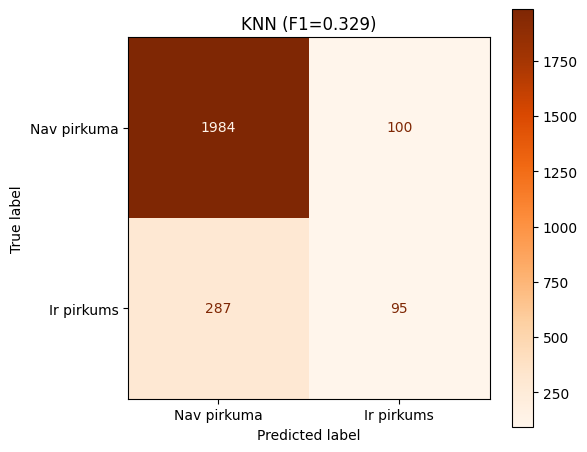

In [36]:
from sklearn.metrics import f1_score

# Aprēķina F1 score pirms grafika
knn_f1 = f1_score(y_test, knn_pred)

# Tikai tad zīmē grafiku
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, knn_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Oranges', ax=ax)
ax.set_title(f'KNN (F1={knn_f1:.3f})')
plt.tight_layout()
plt.show()

**Kāds ir KNN F1 score salīdzinājumā ar pārējiem trim modeļiem?**

| Modelis             | F1 Score | Precision | Recall |
|---------------------|----------|-----------|--------|
| Decision Tree       | 0.637    | 0.71      | 0.58   |
| Random Forest       | 0.628    | 0.75      | 0.54   |
| Logistic Regression | 0.485    | —         | —      |
| **KNN**             | **0.330**| **0.49**  | **0.25**|

KNN ir skaidri **vājākais modelis** šajā uzdevumā. F1 score 0.33 nozīmē, ka
modelis atrod tikai 25% reālo pircēju (recall=0.25) — tas ir sliktāk nekā
pat Logistic Regression. Praktiski tas nozīmē, ka 3 no 4 potenciālajiem
pircējiem paliek neidentificēti.


**Vai KNN priekšrocības (vienkāršība, nav trenēšanas posma) kompensē tā trūkumus (lēnums, mērogošanas prasība)?**

Šajā gadījumā — **nē**. KNN teorētiskās priekšrocības ir:
- Nav trenēšanas posma — modelis vienkārši "iegaumē" datus
- Vienkārši saprotams un implementējams

Taču praksē šis datsets atklāj KNN klasiskos trūkumus:
- **Daudz iezīmju (high dimensionality)** — ar daudzām kolonnām attāluma
  aprēķins kļūst neuzticams. Visi punkti sāk šķist "vienādi tālu", un
  "tuvākā kaimiņa" jēdziens zaudē nozīmi.
- **Klašu nebalanss** — ~85% klientu nepirka, tāpēc tuvākie kaimiņi
  statistiski gandrīz vienmēr ir "nepircēji", neatkarīgi no jaunā klienta
  uzvedības.
- **Mērogošanas prasība** — pat ar `StandardScaler` šie problēmjautājumi
  paliek.

**Kuru K vērtību tu izvēlētos, ja varētu eksperimentēt? Kāpēc K=1 ir riskanti?**

Ar šo datasetu vērts eksperimentēt ar lielākām K vērtībām:

| K vērtība | Risks | Piemērots, ja... |
|-----------|-------|-----------------|
| K=1       | Ļoti augsts overfitting | Nekad nav ieteicams |
| K=5       | Vidējs (pašreizējais) | Mazs, tīrs datsets |
| K=15–21   | Zems | Nebalansēts datsets ✓ |
| K=100+    | Underfitting | Modelis kļūst "stulbs" |

*Kāpēc K=1 ir riskanti?* Ar K=1 modelis pieņem lēmumu pēc viena
vienīga kaimiņa — ja tas ir trokšņains vai izņēmuma gadījums, visa
prognoze ir nepareiza. Piemēram, ja treniņa datos viens "bagāts klients"
ar netipisku uzvedību tomēr nepirka, tad visi jaunie klienti ar līdzīgu
profilu tiks nepareizi klasificēti. K=1 praktiski iegaumē treniņa datus
un nespēj vispārināt.

*Secinājums:* KNN nav piemērots šim uzdevumam. Ar F1=0.33 tas ir par
50% sliktāks nekā Decision Tree. 
